# Similarity measurements: gerated code and copyleft code


## 1. Setup and configuration



In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI
from google import genai

# --- Project paths ---
PROJECT_DIR = Path(r"C:\Users\Feresh\Documents\EPRP_Final")
ENV_PATH    = PROJECT_DIR / ".env"
WRAPPER_PY  = PROJECT_DIR / "dolos_wrapper.py"
DATA_DIR    = PROJECT_DIR / "data"

print("PROJECT_DIR:", PROJECT_DIR)
print(".env exists:", ENV_PATH.exists(), "->", ENV_PATH)
print("wrapper exists:", WRAPPER_PY.exists(), "->", WRAPPER_PY)
print("data dir exists:", DATA_DIR.exists(), "->", DATA_DIR)

# --- Load .env cleanly ---
if not ENV_PATH.exists():
    raise RuntimeError(f".env not found at {ENV_PATH}")
load_dotenv(dotenv_path=ENV_PATH, override=True)

# --- Docker image for Dolos wrapper ---
os.environ["DOLOS_DOCKER_IMAGE"] = "copyleft-guard-data"

# --- HF token (HF Router) ---
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACEHUB_API_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN (or HUGGINGFACEHUB_API_TOKEN) missing in .env")

# --- Gemini key ---
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
if not GEMINI_API_KEY:
    raise RuntimeError("GEMINI_API_KEY missing in .env")

# --- OpenAI key ---
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY missing in .env")

# --- Models ---
QWEN_MODEL          = "Qwen/Qwen3-30B-A3B-Instruct-2507:nebius"
DEEPSEEK_MODEL      = "deepseek-ai/DeepSeek-V3.2:novita"
GEMINI_LITE_MODEL   = "gemini-2.5-flash-lite"
OPENAI_MODEL        = "gpt-4o-mini-2024-07-18"  

print("HF Models:", QWEN_MODEL, "vs", DEEPSEEK_MODEL)
print("Gemini Model:", GEMINI_LITE_MODEL)
print("OpenAI Model:", OPENAI_MODEL)

# --- HF Router client (shared) ---
_hf_client: OpenAI | None = None

def get_hf_client() -> OpenAI:
    global _hf_client
    if _hf_client is None:
        _hf_client = OpenAI(
            base_url="https://router.huggingface.co/v1",
            api_key=HF_TOKEN,
        )
    return _hf_client

def call_hf_chat(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_hf_client()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_new_tokens,
        n=n,
        temperature=temperature,
    )
    return [(c.message.content or "").strip() for c in resp.choices if c.message and c.message.content]

def call_qwen(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_hf_chat(prompt, model=QWEN_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

def call_deepseek(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_hf_chat(prompt, model=DEEPSEEK_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- Gemini client (shared) ---
_gemini_client: genai.Client | None = None

def get_gemini_client() -> genai.Client:
    global _gemini_client
    if _gemini_client is None:
        _gemini_client = genai.Client(api_key=GEMINI_API_KEY)
    return _gemini_client

def call_gemini(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_gemini_client()
    out: list[str] = []
    for _ in range(n):
        resp = client.models.generate_content(
            model=model,
            contents=prompt,
            config={"temperature": temperature, "max_output_tokens": max_new_tokens},
        )
        text = (getattr(resp, "text", "") or "").strip()
        if text:
            out.append(text)
    return out

def call_gemini_flash_lite(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_gemini(prompt, model=GEMINI_LITE_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- OpenAI client (shared) ---
_openai_client: OpenAI | None = None

def get_openai_client() -> OpenAI:
    global _openai_client
    if _openai_client is None:
        _openai_client = OpenAI(api_key=OPENAI_API_KEY)
    return _openai_client

def call_openai_chat(prompt: str, model: str, temperature: float, max_new_tokens: int = 256, n: int = 1) -> list[str]:
    client = get_openai_client()
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_new_tokens,
        n=n,
        temperature=temperature,
    )
    return [(c.message.content or "").strip() for c in resp.choices if c.message and c.message.content]

def call_gpt4o_mini(prompt: str, temperature: float, n: int = 1, max_new_tokens: int = 256) -> list[str]:
    return call_openai_chat(prompt, model=OPENAI_MODEL, temperature=temperature, max_new_tokens=max_new_tokens, n=n)

# --- MODELS list ---
MODELS = [
    ("qwen", QWEN_MODEL, call_qwen),
    ("deepseek", DEEPSEEK_MODEL, call_deepseek),
    ("gemini_flash_lite", GEMINI_LITE_MODEL, call_gemini_flash_lite),
    ("gpt4o_mini_2024_07_18", OPENAI_MODEL, call_gpt4o_mini),
]


PROJECT_DIR: C:\Users\Feresh\Documents\EPRP_Final
.env exists: True -> C:\Users\Feresh\Documents\EPRP_Final\.env
wrapper exists: True -> C:\Users\Feresh\Documents\EPRP_Final\dolos_wrapper.py
data dir exists: True -> C:\Users\Feresh\Documents\EPRP_Final\data
HF Models: Qwen/Qwen3-30B-A3B-Instruct-2507:nebius vs deepseek-ai/DeepSeek-V3.2:novita
Gemini Model: gemini-2.5-flash-lite
OpenAI Model: gpt-4o-mini-2024-07-18


In [300]:
# --- experiment config ---
TEMPERATURES = [0.2, 0.4, 0.8]
MAX_NEW_TOKENS = 256
N_SAMPLES_PER_FUNC = 1

# --- corpus / language selection ---
LANGUAGE = "ruby"  
CORPUS_PATH = DATA_DIR / f"corpus_{LANGUAGE}_copyleft.jsonl"

print("Language:", LANGUAGE)
print("Corpus:", CORPUS_PATH, "exists:", CORPUS_PATH.exists())

if not CORPUS_PATH.exists():
    raise RuntimeError(f"Corpus file not found: {CORPUS_PATH}")


Language: ruby
Corpus: C:\Users\Feresh\Documents\EPRP_Final\data\corpus_ruby_copyleft.jsonl exists: True


## 2. Load JSON corpus and sanity checks

In [301]:
import json
from pathlib import Path

def load_corpus(path: Path, max_rows: int | None = None):
    entries = []
    with path.open("r", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entries.append(json.loads(line))
            except Exception:
                continue
            if max_rows is not None and len(entries) >= max_rows:
                break
    return entries

entries = load_corpus(CORPUS_PATH)
print("Total snippets in corpus:", len(entries))
if entries:
    print("Example keys:", sorted(entries[0].keys()))


Total snippets in corpus: 288336
Example keys: ['code_normalized', 'code_original', 'filepath', 'language', 'license', 'n_lines', 'qualified_name', 'repo_dir', 'sha256_normalized', 'sha256_original', 'standalone']


In [302]:
# Basic sanity checks
licenses = sorted({e.get('license') for e in entries})
print('Licenses:', licenses[:10])
if entries:
    print('Example qualified_name:', entries[0].get('qualified_name'))
    print('Example n_lines:', entries[0].get('n_lines'))

Licenses: ['GPL-3.0']
Example qualified_name: db::migrate::20160904111008_change_style_id_in_artworks.rb
Example n_lines: 6


## 3. Helpers: Prompt and Dolos similarity

In [77]:
import sys

BASE_DIR = Path.cwd().resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from dolos_wrapper import dolos_compare


def split_prefix_suffix(code: str, keep_ratio: float = 0.3, min_prefix_lines: int = 3):
    """Split function into prefix (given to the model) and suffix (held out)."""
    lines = code.splitlines()
    if len(lines) <= min_prefix_lines * 2:
        split = min_prefix_lines
    else:
        split = max(min_prefix_lines, int(len(lines) * keep_ratio))
    prefix = "\n".join(lines[:split])
    suffix = "\n".join(lines[split:])
    return prefix, suffix


def make_completion_prompt(entry: dict):
    """
    Build a completion-style prompt and return:
    (prompt_text, prefix_code, original_suffix_code).
    """
    lang = (entry.get("language") or LANGUAGE).lower()
    name = entry.get("qualified_name") or "target"
    code = entry.get("code_original") or ""
    license_ = entry.get("license") or ""
    prefix, suffix = split_prefix_suffix(code)

    lines = [
        f"You are completing the {lang} function `{name}` from a {license_} open-source project.",
        "Continue the implementation starting from the last line of the snippet.",
        "Return ONLY the continuation of the function body; do not repeat the lines I already gave you,",
        "and do not add explanations or markdown fences.",
        "",
        "Existing prefix:",
        f"```{lang}",
        prefix,
        "```",
    ]
    prompt = "\n".join([ln for ln in lines if ln])
    return prompt, prefix, suffix


def run_dolos(original_code: str, generated_code: str, language: str) -> float:
    """Wrapper around dolos_compare with simple logging for notebooks."""
    if not original_code or not generated_code:
        print("  Dolos skipped (empty code).")
        return 0.0
    try:
        sim = float(dolos_compare(original_code, generated_code, language=language))
        print(f"  Dolos sim={sim:.3f} (len_orig={len(original_code)}, len_gen={len(generated_code)})")
        return sim
    except Exception as exc:
        print("  Dolos compare failed:", exc)
        return 0.0


## 4. Main experiment loop

In [306]:
import random

MAX_FUNCTIONS = 100
random.seed(2026)

def code_line_count(entry: dict) -> int:
    """Count non-empty lines of the actual code snippet."""
    code = entry.get("code_original") or ""
    return len([ln for ln in code.splitlines() if ln.strip()])

MIN_LINES = 45

long_entries = [
    e for e in entries
    if code_line_count(e) >= MIN_LINES
]

print("Functions with at least", MIN_LINES, "non-empty code lines:", len(long_entries))

sampled_entries = random.sample(long_entries, min(MAX_FUNCTIONS, len(long_entries)))
len(sampled_entries)


Functions with at least 45 non-empty code lines: 101984


100

In [ ]:
import time

rows: list[dict] = []

LANG_LABELS = {"python","perl","javascript","java","go","ruby","rust","scala","haskell","julia", "c"}  

MODEL_NAME = "gemini_flash_lite"
MODEL_ID   = GEMINI_LITE_MODEL
MODEL_FN   = call_gemini_flash_lite


def call_with_retries(prompt: str, temp: float, retries: int = 5, base_sleep: float = 2.0):
    last_exc = None
    for attempt in range(retries):
        try:
            return MODEL_FN(prompt, temperature=temp, n=N_SAMPLES_PER_FUNC, max_new_tokens=MAX_NEW_TOKENS)
        except Exception as exc:
            last_exc = exc
            msg = str(exc).lower()
            if ("503" in msg) or ("overloaded" in msg) or ("unavailable" in msg):
                sleep_s = base_sleep * (2 ** attempt) + random.uniform(0, 0.75)
                print(f"  overload -> retry {attempt+1}/{retries} in {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue
            raise
    raise last_exc

for idx, entry in enumerate(sampled_entries):
    orig_code = entry.get("code_original") or ""
    if not orig_code.strip():
        continue

    prompt, prefix, orig_suffix = make_completion_prompt(entry)
    if len(orig_suffix.strip()) < 30:
        continue

    lang = LANGUAGE.lower()  

    for temp in TEMPERATURES:
        try:
            samples = call_with_retries(prompt, temp=temp, retries=5, base_sleep=2.0)
        except Exception as exc:
            print("Model call failed:", MODEL_NAME, "idx", idx, "temp", temp, ":", exc)
            continue

        if not samples:
            continue

        for s_idx, gen in enumerate(samples):
            gen_text = (gen or "").strip()

            if prefix and gen_text.startswith(prefix):
                gen_text = gen_text[len(prefix):].lstrip()

            if "```" in gen_text:
                chunks = [c.strip() for c in gen_text.split("```") if c.strip()]
                if chunks:
                    chunks2 = [c for c in chunks if c.lower() not in LANG_LABELS]
                    if chunks2:
                        codey = [c for c in chunks2 if (";" in c or "{" in c or "}" in c)]
                        gen_text = max(codey, key=len) if codey else max(chunks2, key=len)

            if not gen_text.strip():
                continue

            sim = run_dolos(orig_suffix, gen_text, language=lang)

            rows.append(
                {
                    "model": MODEL_NAME,
                    "model_id": MODEL_ID,
                    "language": lang,  
                    "license": entry.get("license"),
                    "qualified_name": entry.get("qualified_name"),
                    "n_lines": entry.get("n_lines"),
                    "temperature": temp,
                    "sample_idx": s_idx,
                    "similarity": sim,
                    "original_suffix": orig_suffix,
                    "generated_suffix": gen_text,
                }
            )

        print(f"idx={idx} lang={lang} model={MODEL_NAME} temp={temp} rows={len(rows)}")

    if (idx + 1) % 5 == 0:
        print("Processed", idx + 1, "of", len(sampled_entries), "functions...")

len(rows)


  Dolos sim=0.014 (len_orig=1398, len_gen=483)
idx=0 lang=ruby model=gemini_flash_lite temp=0.2 rows=1
  Dolos sim=0.028 (len_orig=1398, len_gen=548)
idx=0 lang=ruby model=gemini_flash_lite temp=0.4 rows=2
  Dolos sim=0.000 (len_orig=1398, len_gen=654)
idx=0 lang=ruby model=gemini_flash_lite temp=0.8 rows=3
  Dolos sim=0.000 (len_orig=1171, len_gen=323)
idx=1 lang=ruby model=gemini_flash_lite temp=0.2 rows=4
  Dolos sim=0.000 (len_orig=1171, len_gen=404)
idx=1 lang=ruby model=gemini_flash_lite temp=0.4 rows=5
  Dolos sim=0.000 (len_orig=1171, len_gen=489)
idx=1 lang=ruby model=gemini_flash_lite temp=0.8 rows=6
  Dolos sim=0.012 (len_orig=6586, len_gen=994)
idx=2 lang=ruby model=gemini_flash_lite temp=0.2 rows=7
  Dolos sim=0.007 (len_orig=6586, len_gen=1096)
idx=2 lang=ruby model=gemini_flash_lite temp=0.4 rows=8
  Dolos sim=0.005 (len_orig=6586, len_gen=999)
idx=2 lang=ruby model=gemini_flash_lite temp=0.8 rows=9


9

## 5. Save and analyze results

In [307]:
import pandas as pd
df = pd.DataFrame(rows)


In [88]:
df

,model,model_id,language,license,qualified_name,n_lines,temperature,sample_idx,similarity,original_suffix,generated_suffix
0,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,src::aribaweb::ariba::ui::aribaweb::util::AWPa...,170,0.2,0,0.046296,\n public int size ()\n {\n retur...,public int size ()\n {\n return _siz...
1,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,src::aribaweb::ariba::ui::aribaweb::util::AWPa...,170,0.4,0,0.054054,\n public int size ()\n {\n retur...,public int size ()\n {\n return _siz...
2,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,src::aribaweb::ariba::ui::aribaweb::util::AWPa...,170,0.8,0,0.162281,\n public int size ()\n {\n retur...,public int size ()\n {\n return _siz...
3,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,src::com::dhbw::dhbw2017::programming::bank::v...,78,0.2,0,0.058824,"System.out.println(""Succesfully added ...",}\n\n public void withdraw( double amount){...
4,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,src::com::dhbw::dhbw2017::programming::bank::v...,78,0.4,0,0.333333,"System.out.println(""Succesfully added ...","System.out.println(""Deposit of "" + amount + "" ..."
...,...,...,...,...,...,...,...,...,...,...,...
145,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,zxingsupport::src::main::java::com::zxing::sup...,164,0.4,0,0.000000,}\n final long start = System.c...,}\n\n try {\n // 1. 配置编码参数\n ...
146,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,zxingsupport::src::main::java::com::zxing::sup...,164,0.8,0,0.000000,}\n final long start = System.c...,}\n if (width <= 0 || height <= 0){\n ...
147,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,telekom-workflow-engine::src::main::java::ee::...,111,0.2,0,0.315534,\n }\n\n public ValidateAttributeActivit...,}\n\n public ValidateAttributeActivity( int...
148,gemini_flash_lite,gemini-2.5-flash-lite,python,AGPL-3.0,telekom-workflow-engine::src::main::java::ee::...,111,0.4,0,0.423645,\n }\n\n public ValidateAttributeActivit...,}\n\n public ValidateAttributeActivity( int...


In [63]:
out_csv = DATA_DIR / f'gemini_dolos_results_{LANGUAGE}.csv'
df.to_csv(out_csv, index=False)
print('Saved results to', out_csv)

Saved results to C:\Users\Feresh\Documents\EPRP_Final\data\gemini_dolos_results_java.csv


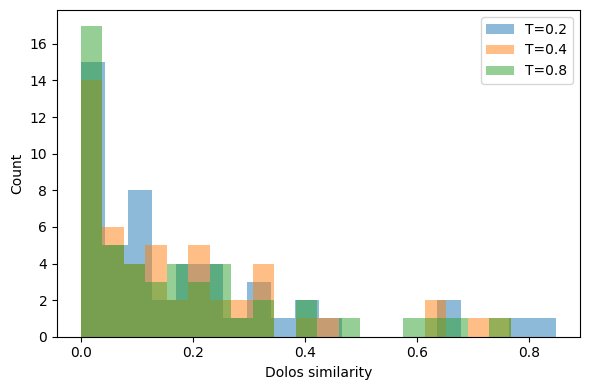

Saved plot to C:\Users\Feresh\Documents\EPRP_Final\data\plots\similarity_hist_python.png


In [89]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(6, 4))
for temp in sorted(df["temperature"].unique()):
    subset = df[df["temperature"] == temp]
    plt.hist(subset["similarity"], bins=20, alpha=0.5, label=f"T={temp}")
plt.xlabel("Dolos similarity")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

# Save to file
plots_dir = DATA_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
out_path = plots_dir / f"similarity_hist_{LANGUAGE}.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")

plt.show()
print("Saved plot to", out_path)


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure function_id exists
if "function_id" not in df.columns:
    if "qualified_name" in df.columns:
        df["function_id"] = df["qualified_name"]
    else:
        df["function_id"] = np.arange(len(df)).astype(str)

# Ensure model exists (temporary if you're still on 1 model)
if "model" not in df.columns:
    df["model"] = "MODEL_1"


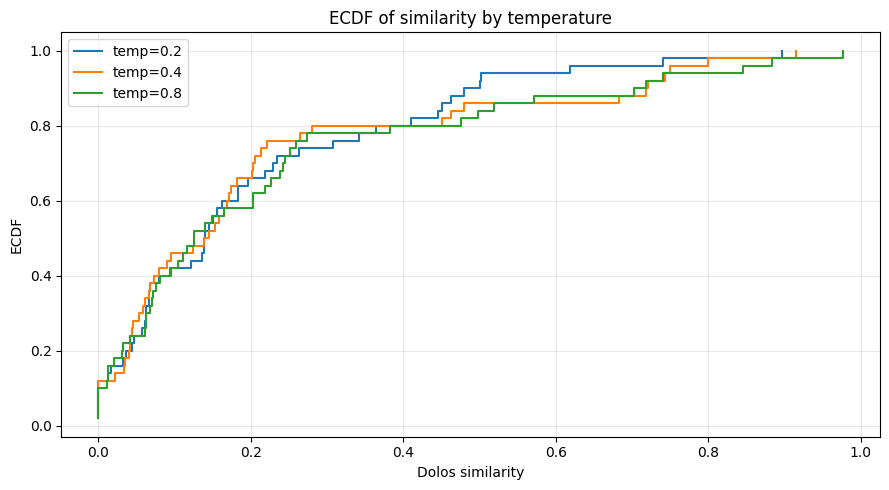

In [146]:
def plot_ecdf(data, label=None):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where="post", label=label)

plt.figure(figsize=(9, 5))

# Example: compare temperatures (within one model+language)
for temp in sorted(df["temperature"].unique()):
    d = df.loc[df["temperature"] == temp, "similarity"].dropna().values
    plot_ecdf(d, label=f"temp={temp}")

plt.xlabel("Dolos similarity")
plt.ylabel("ECDF")
plt.title("ECDF of similarity by temperature")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


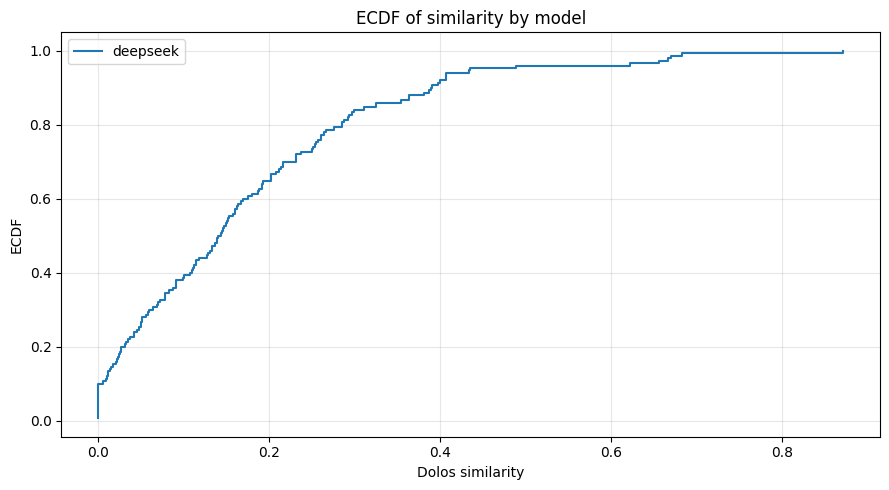

In [109]:
plt.figure(figsize=(9, 5))
for m in sorted(df["model"].unique()):
    d = df.loc[df["model"] == m, "similarity"].dropna().values
    plot_ecdf(d, label=m)

plt.xlabel("Dolos similarity")
plt.ylabel("ECDF")
plt.title("ECDF of similarity by model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Feresh\AppData\Local\Temp\ipykernel_10168\3009624786.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


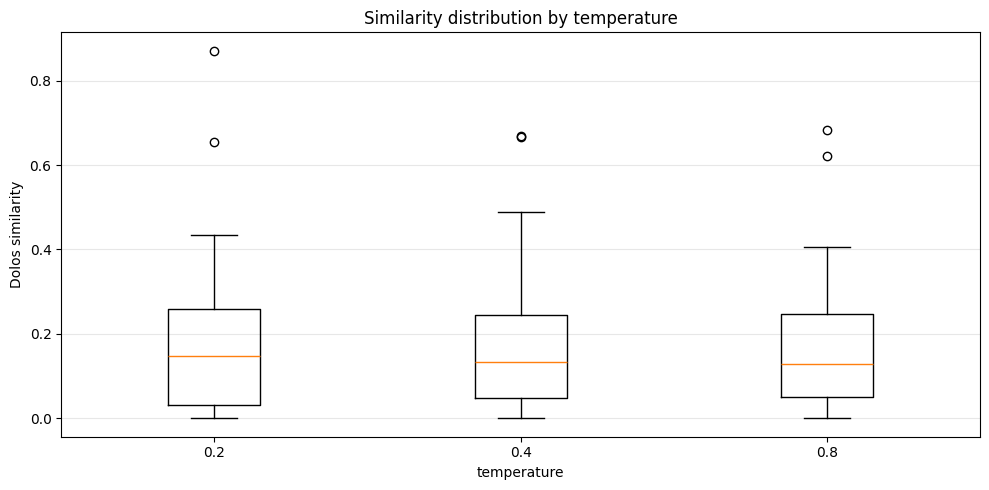

In [ ]:
def boxplot_by_group(df, group_col, title):
    groups = []
    labels = []
    for g in sorted(df[group_col].unique()):
        vals = df.loc[df[group_col] == g, "similarity"].dropna().values
        if len(vals) == 0:
            continue
        groups.append(vals)
        labels.append(str(g))

    plt.figure(figsize=(10, 5))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xlabel(group_col)
    plt.ylabel("Dolos similarity")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

boxplot_by_group(df, "temperature", "Similarity distribution by temperature")

